# Analiza histogramowa i boxplotowa pierwszego utworzonego zbioru
W tym notatniku wczytujemy pierwszy utworzony zbiór po imputacji i skalowaniu, a następnie wykonujemy analizę rozkładów cech numerycznych za pomocą histogramów i wykresów pudełkowych.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

In [3]:
data_dir = Path("./data")

# Wpisz nazwe konkretnego pliku dla tego notatnika
dataset_filename = "loan_data_automl_standard.csv"

selected_dataset_path = data_dir / dataset_filename
if not selected_dataset_path.exists():
    available_files = sorted([p.name for p in data_dir.glob("loan_data_*_*.csv")])
    raise FileNotFoundError(
        f"Nie znaleziono pliku: {selected_dataset_path}\nDostepne pliki: {available_files}"
    )

print(f"Wczytywany zbior: {selected_dataset_path}")
df = pd.read_csv(selected_dataset_path)
display(df.head())

Wczytywany zbior: data/loan_data_automl_standard.csv


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,-0.956835,male,Master,-0.103817,-0.848268,RENT,4.055991,PERSONAL,0.791954,4.049493,-0.742434,0.158979,No,1
1,-1.122927,female,High School,-0.847374,-0.898721,OWN,-1.359942,EDUCATION,0.045584,-0.687236,-1.002007,-0.692640,Yes,0
2,-0.458561,female,High School,-0.845430,-0.400006,MORTGAGE,-0.651037,HOMEIMPROVEMENT,0.654910,3.471843,-0.742434,0.051718,No,1
3,-0.790744,female,Bachelor,-0.006551,-0.898721,RENT,4.055991,MEDICAL,1.486129,3.471843,-1.002007,0.881788,No,1
4,-0.624652,male,Master,-0.176259,-0.732483,RENT,4.055991,MEDICAL,0.995212,4.511613,-0.482860,-0.965119,No,1


In [4]:
print("Ksztalt danych:", df.shape)
print("\nTypy kolumn:")
display(df.dtypes.to_frame("dtype"))

print("\nBraki danych:")
display(df.isna().sum().to_frame("missing_count"))

num_cols = [
    col for col in df.select_dtypes(include=[np.number]).columns.tolist()
    if col != "loan_status"
]
print(f"\nLiczba kolumn numerycznych (bez loan_status): {len(num_cols)}")
print("Kolumny numeryczne:", num_cols)

Ksztalt danych: (45000, 14)

Typy kolumn:


,dtype
person_age,float64
person_gender,object
person_education,object
person_income,float64
person_emp_exp,float64
person_home_ownership,object
loan_amnt,float64
loan_intent,object
loan_int_rate,float64
loan_percent_income,float64



Braki danych:


,missing_count
person_age,0
person_gender,0
person_education,0
person_income,0
person_emp_exp,0
person_home_ownership,0
loan_amnt,0
loan_intent,0
loan_int_rate,0
loan_percent_income,0



Liczba kolumn numerycznych (bez loan_status): 8
Kolumny numeryczne: ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']


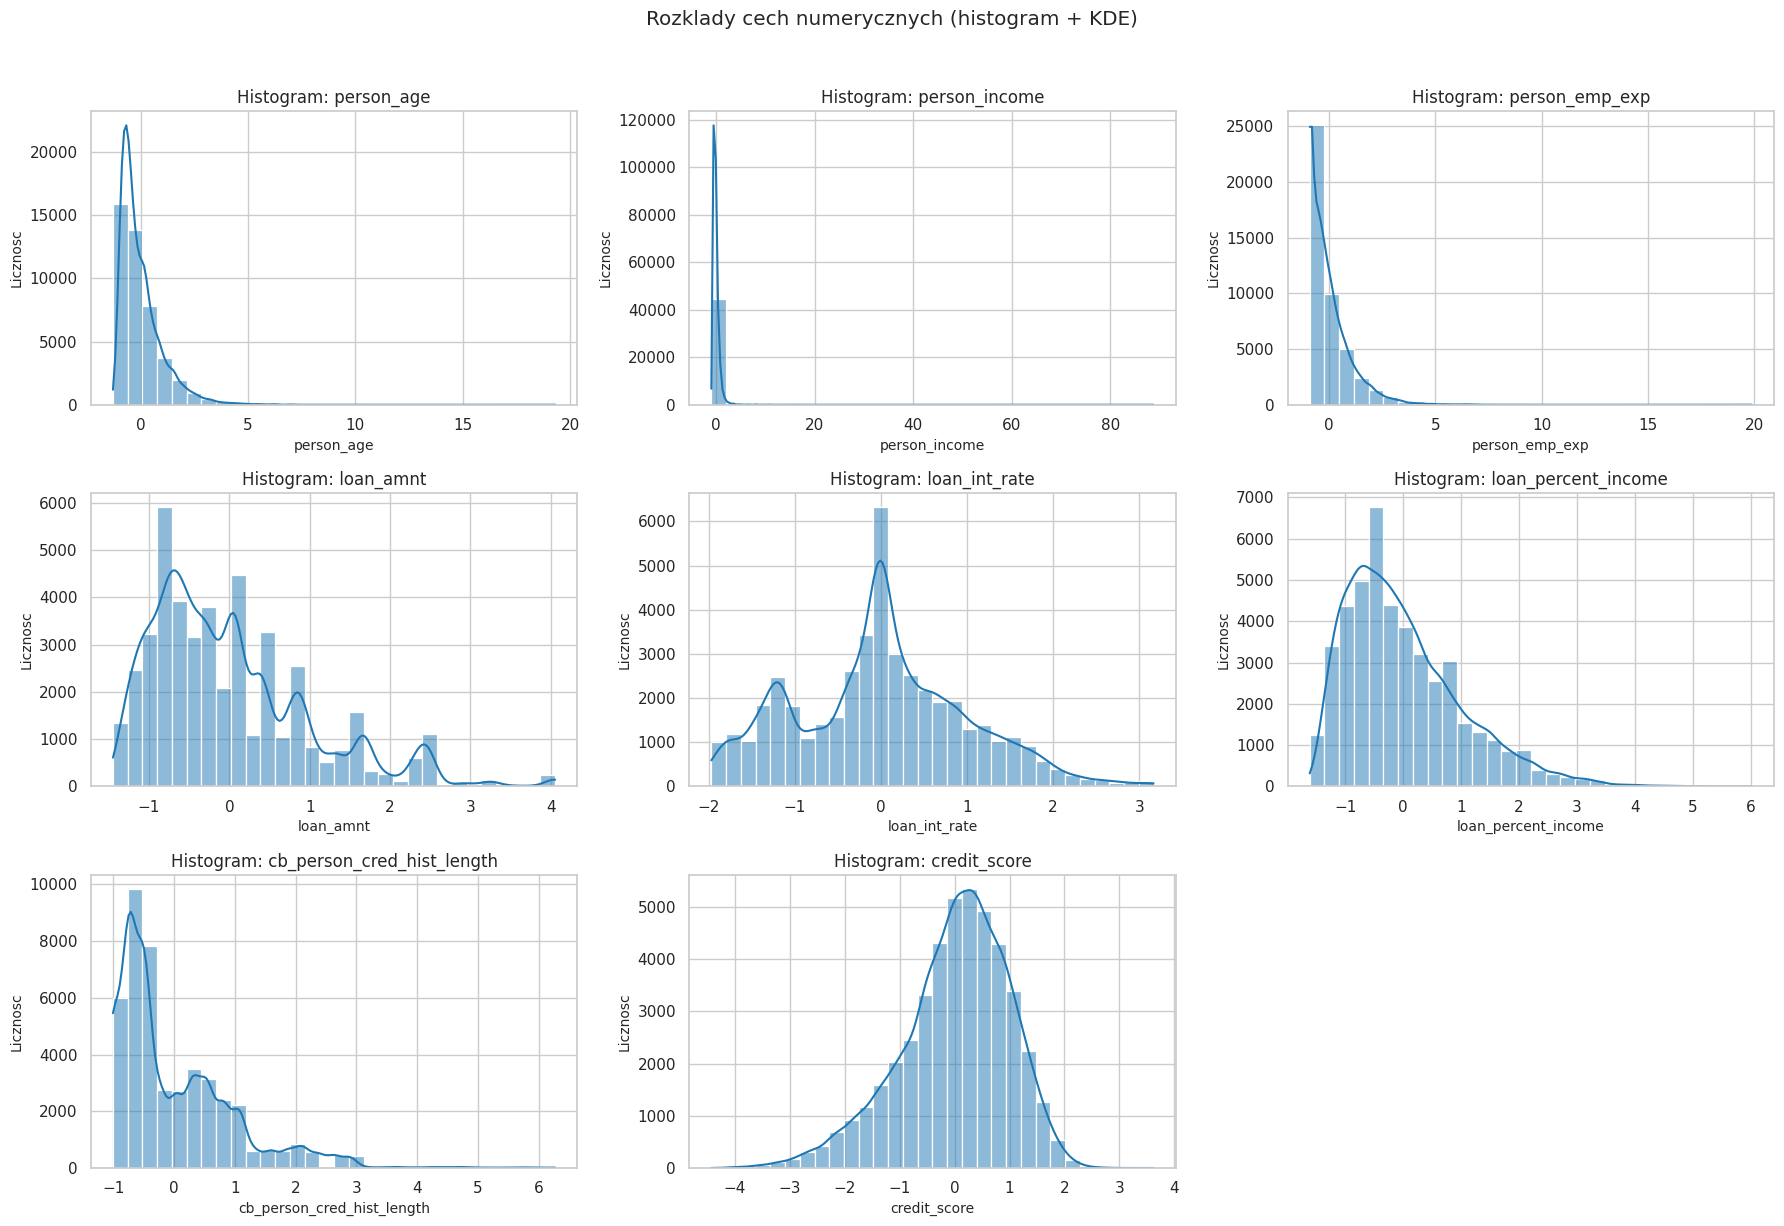

In [5]:
# Analiza histogramowa wszystkich kolumn numerycznych
n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols)) if num_cols else 1

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(num_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i], color="#1f77b4")
    axes[i].set_title(f"Histogram: {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Licznosc")

for j in range(len(num_cols), len(axes)):
    axes[j].axis("off")

plt.suptitle("Rozklady cech numerycznych (histogram + KDE)", y=1.02)
plt.tight_layout()
plt.show()

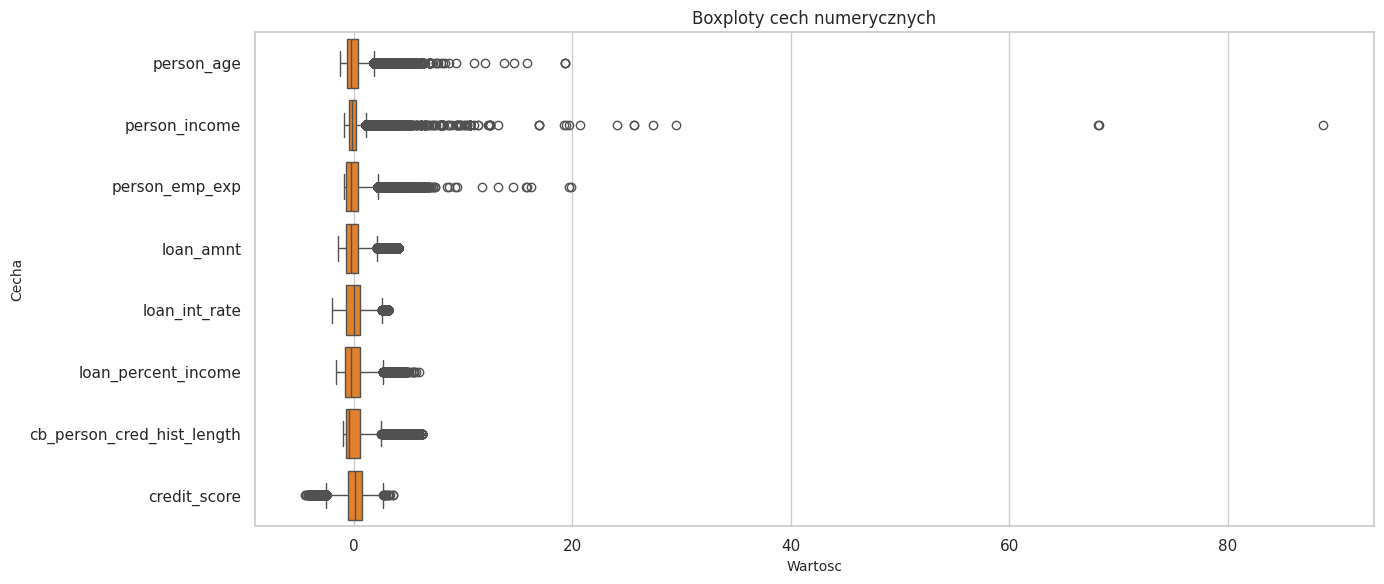

In [6]:
# Analiza boxplotowa wszystkich kolumn numerycznych
if num_cols:
    plot_df = df[num_cols].melt(var_name="cecha", value_name="wartosc")
    
    plt.figure(figsize=(14, max(6, 0.5 * len(num_cols))))
    sns.boxplot(data=plot_df, y="cecha", x="wartosc", orient="h", color="#ff7f0e")
    plt.title("Boxploty cech numerycznych")
    plt.xlabel("Wartosc")
    plt.ylabel("Cecha")
    plt.tight_layout()
    plt.show()
else:
    print("Brak kolumn numerycznych do analizy boxplotowej.")

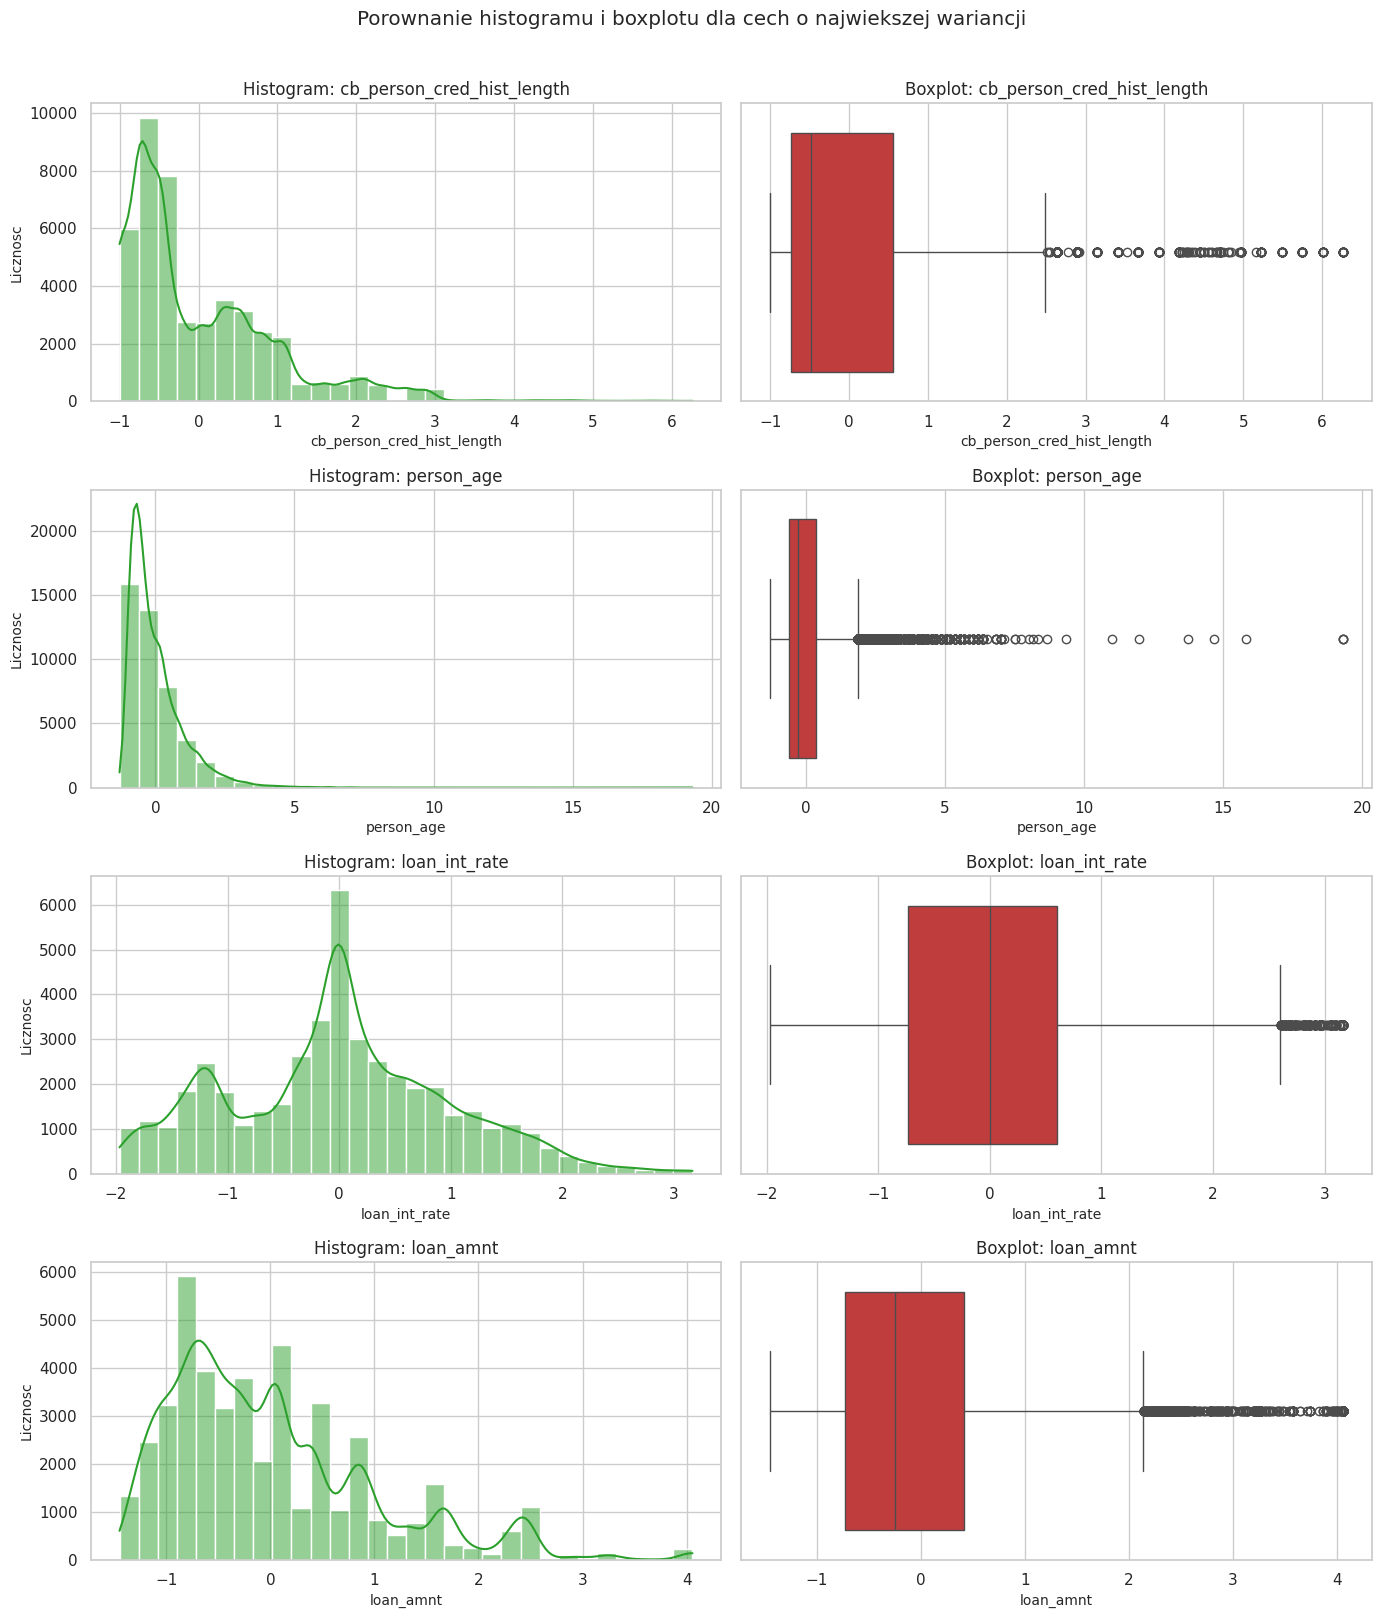

In [7]:
# Porownanie histogramow i boxplotow dla wybranych cech
top_features = df[num_cols].var(numeric_only=True).sort_values(ascending=False).head(4).index.tolist() if num_cols else []

if top_features:
    fig, axes = plt.subplots(len(top_features), 2, figsize=(14, 4 * len(top_features)))
    if len(top_features) == 1:
        axes = np.array([axes])

    for i, feature in enumerate(top_features):
        sns.histplot(df[feature], bins=30, kde=True, ax=axes[i, 0], color="#2ca02c")
        axes[i, 0].set_title(f"Histogram: {feature}")
        axes[i, 0].set_xlabel(feature)
        axes[i, 0].set_ylabel("Licznosc")

        sns.boxplot(x=df[feature], ax=axes[i, 1], color="#d62728")
        axes[i, 1].set_title(f"Boxplot: {feature}")
        axes[i, 1].set_xlabel(feature)

    plt.suptitle("Porownanie histogramu i boxplotu dla cech o najwiekszej wariancji", y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print("Brak kolumn numerycznych do porownania histogramow i boxplotow.")

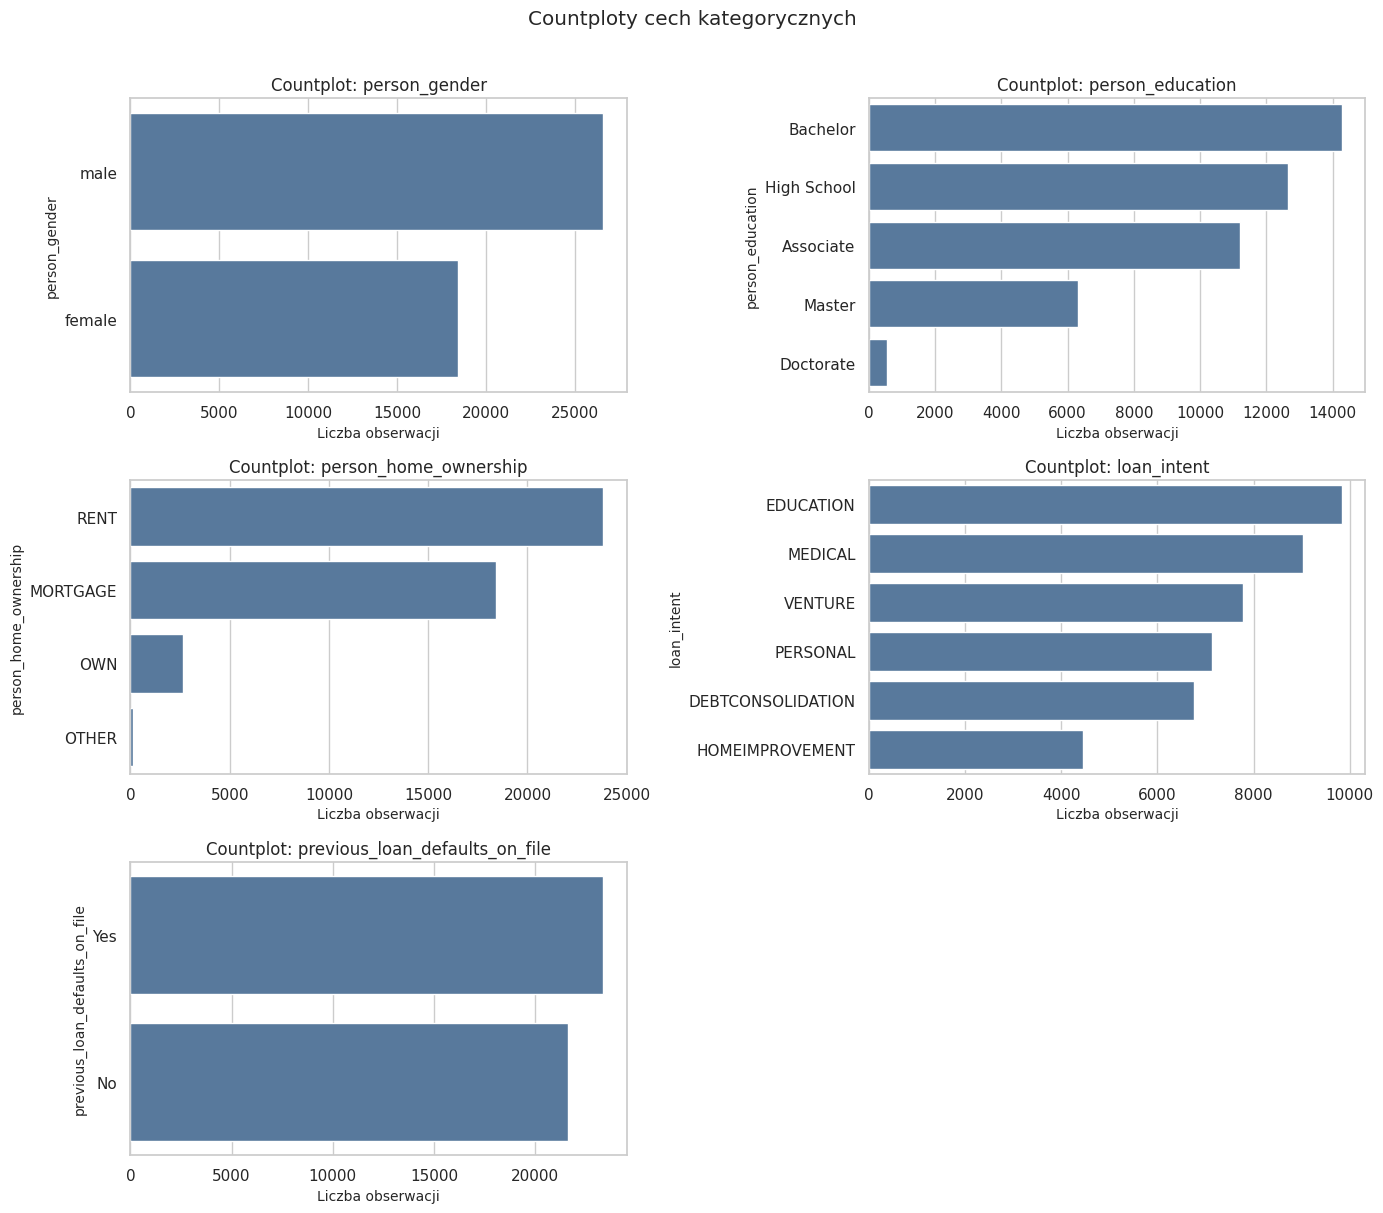

In [9]:
# Countploty dla kolumn nienumerycznych (bez loan_status) w subplotach
cat_cols = [
    col for col in df.select_dtypes(exclude=[np.number]).columns.tolist()
    if col != "loan_status"
 ]

if not cat_cols:
    print("Brak kolumn nienumerycznych do wizualizacji countplot.")
else:
    n_cols_plot = 2
    n_rows_plot = int(np.ceil(len(cat_cols) / n_cols_plot))

    fig, axes = plt.subplots(
        n_rows_plot, n_cols_plot, figsize=(14, 4 * n_rows_plot)
    )
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(cat_cols):
        order = df[col].astype(str).value_counts().index
        sns.countplot(
            y=df[col].astype(str),
            order=order,
            color="#4c78a8",
            ax=axes[i]
        )
        axes[i].set_title(f"Countplot: {col}")
        axes[i].set_xlabel("Liczba obserwacji")
        axes[i].set_ylabel(col)

    for j in range(len(cat_cols), len(axes)):
        axes[j].axis("off")

    plt.suptitle("Countploty cech kategorycznych", y=1.01)
    plt.tight_layout()
    plt.show()